In [ ]:
# Descargar el CSV spotify
# Hacer el PCA, TSME, UMAP para pasar de 15 caracteristicas a 2
# Hacer un plot de esos datos
# Volver al dataFrame original
# Hacer un ELBOW,SHILHOTTE
# Hacer un K-MEANS
# Un plot del K-MEANS

In [24]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("/content/genres_v2.csv")

/tmp/ipython-input-3210578576.py:8: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/genres_v2.csv")


In [25]:
df.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,id,uri,track_href,analysis_url,duration_ms,time_signature,genre,song_name,Unnamed: 0,title
0,0.831,0.814,2,-7.364,1,0.4200,0.0598,0.013400,0.0556,0.3890,...,2Vc6NJ9PW9gD9q343XFRKx,spotify:track:2Vc6NJ9PW9gD9q343XFRKx,https://api.spotify.com/v1/tracks/2Vc6NJ9PW9gD...,https://api.spotify.com/v1/audio-analysis/2Vc6...,124539,4,Dark Trap,Mercury: Retrograde,NaN,NaN
1,0.719,0.493,8,-7.230,1,0.0794,0.4010,0.000000,0.1180,0.1240,...,7pgJBLVz5VmnL7uGHmRj6p,spotify:track:7pgJBLVz5VmnL7uGHmRj6p,https://api.spotify.com/v1/tracks/7pgJBLVz5Vmn...,https://api.spotify.com/v1/audio-analysis/7pgJ...,224427,4,Dark Trap,Pathology,NaN,NaN
2,0.850,0.893,5,-4.783,1,0.0623,0.0138,0.000004,0.3720,0.0391,...,0vSWgAlfpye0WCGeNmuNhy,spotify:track:0vSWgAlfpye0WCGeNmuNhy,https://api.spotify.com/v1/tracks/0vSWgAlfpye0...,https://api.spotify.com/v1/audio-analysis/0vSW...,98821,4,Dark Trap,Symbiote,NaN,NaN
3,0.476,0.781,0,-4.710,1,0.1030,0.0237,0.000000,0.1140,0.1750,...,0VSXnJqQkwuH2ei1nOQ1nu,spotify:track:0VSXnJqQkwuH2ei1nOQ1nu,https://api.spotify.com/v1/tracks/0VSXnJqQkwuH...,https://api.spotify.com/v1/audio-analysis/0VSX...,123661,3,Dark Trap,ProductOfDrugs (Prod. The Virus and Antidote),NaN,NaN
4,0.798,0.624,2,-7.668,1,0.2930,0.2170,0.000000,0.1660,0.5910,...,4jCeguq9rMTlbMmPHuO7S3,spotify:track:4jCeguq9rMTlbMmPHuO7S3,https://api.spotify.com/v1/tracks/4jCeguq9rMTl...,https://api.spotify.com/v1/audio-analysis/4jCe...,123298,4,Dark Trap,Venom,NaN,NaN


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42305 entries, 0 to 42304
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      42305 non-null  float64
 1   energy            42305 non-null  float64
 2   key               42305 non-null  int64  
 3   loudness          42305 non-null  float64
 4   mode              42305 non-null  int64  
 5   speechiness       42305 non-null  float64
 6   acousticness      42305 non-null  float64
 7   instrumentalness  42305 non-null  float64
 8   liveness          42305 non-null  float64
 9   valence           42305 non-null  float64
 10  tempo             42305 non-null  float64
 11  type              42305 non-null  object 
 12  id                42305 non-null  object 
 13  uri               42305 non-null  object 
 14  track_href        42305 non-null  object 
 15  analysis_url      42305 non-null  object 
 16  duration_ms       42305 non-null  int64 

In [27]:
# Crea una copia independiente del DataFrame original
df_trabajo = df.copy()

In [28]:
df_numerico = df_trabajo.select_dtypes(include=['number'])

In [17]:
print("Columnas restantes después de filtrar:")
print(df_numerico.columns)

Columnas restantes después de filtrar:
Index(['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms', 'time_signature', 'Unnamed: 0', 'title'],
      dtype='object')


In [29]:
df_final = df_numerico.drop(columns=['Unnamed: 0'], axis=1)

# Muestra la lista final de columnas para confirmación
print("\nColumnas finales en el DataFrame de análisis:")
print(df_final.columns)


Columnas finales en el DataFrame de análisis:
Index(['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms', 'time_signature'],
      dtype='object')


In [30]:
df_final.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0.831,0.814,2,-7.364,1,0.4200,0.0598,0.013400,0.0556,0.3890,156.985,124539,4
1,0.719,0.493,8,-7.230,1,0.0794,0.4010,0.000000,0.1180,0.1240,115.080,224427,4
2,0.850,0.893,5,-4.783,1,0.0623,0.0138,0.000004,0.3720,0.0391,218.050,98821,4
3,0.476,0.781,0,-4.710,1,0.1030,0.0237,0.000000,0.1140,0.1750,186.948,123661,3
4,0.798,0.624,2,-7.668,1,0.2930,0.2170,0.000000,0.1660,0.5910,147.988,123298,4


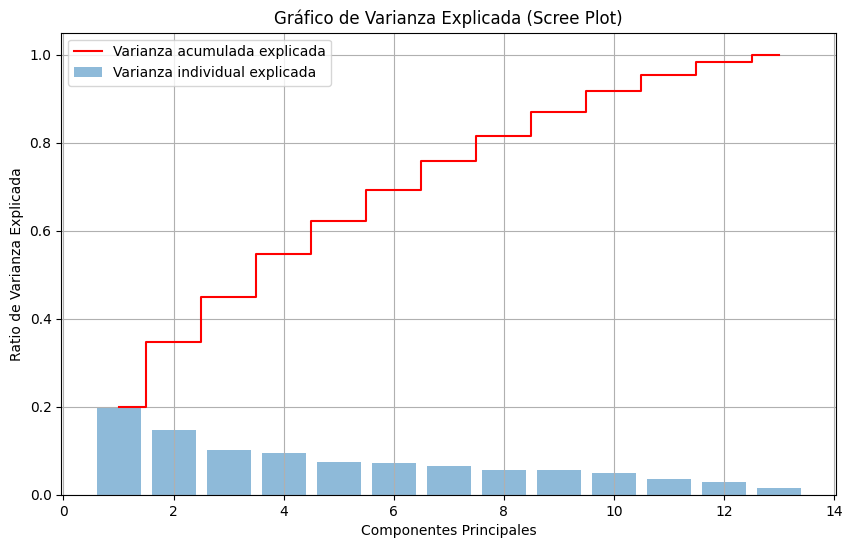

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# 1. ESTANDARIZACIÓN (SCALING)
# ---------------------------------------------------------
# Instanciamos el objeto StandardScaler
scaler = StandardScaler()

# Ajustamos y transformamos tu 'df_final'
# OJO: Esto devuelve un array de numpy, no un DataFrame, por eso lo guardamos en una variable nueva
datos_escalados = scaler.fit_transform(df_final)

# (Opcional) Si quieres verlo como DataFrame para chequear que la media es ~0:
# df_escalado_check = pd.DataFrame(datos_escalados, columns=df_final.columns)
# print(df_escalado_check.describe().round(2))


# ---------------------------------------------------------
# 2. APLICAR PCA
# ---------------------------------------------------------
# Inicialmente no le decimos cuántos componentes. Dejamos que calcule todos.
pca = PCA()
pca.fit(datos_escalados)


# ---------------------------------------------------------
# 3. VISUALIZACIÓN: ELIJE CUÁNTOS COMPONENTES
# ---------------------------------------------------------
# Varianza explicada por cada componente
varianza_explicada = pca.explained_variance_ratio_

# Varianza acumulada (suma progresiva)
varianza_acumulada = np.cumsum(varianza_explicada)

plt.figure(figsize=(10, 6))

# Gráfico de barras para la varianza individual
plt.bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.5, align='center',
        label='Varianza individual explicada')

# Gráfico de línea para la varianza acumulada
plt.step(range(1, len(varianza_acumulada) + 1), varianza_acumulada, where='mid',
         label='Varianza acumulada explicada', color='red')

plt.ylabel('Ratio de Varianza Explicada')
plt.xlabel('Componentes Principales')
plt.legend(loc='best')
plt.title('Gráfico de Varianza Explicada (Scree Plot)')
plt.grid(True)
plt.show()

In [34]:
# Elegimos 8 componentes basándonos en el gráfico (aprox 80% de varianza)
pca_final = PCA(n_components=8)

# Entrenamos y transformamos
X_pca = pca_final.fit_transform(df_final)

# Convertimos a DataFrame para que sea fácil de ver
cols_pca = [f'PC{i+1}' for i in range(8)]
df_pca_final = pd.DataFrame(X_pca, columns=cols_pca)

print("Dimensiones finales:", df_pca_final.shape)
df_pca_final.head()

Dimensiones finales: (42305, 8)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-126326.846952,4.895401,-3.071810,-1.328835,0.334049,-0.004481,0.062866,0.075796
1,-26438.845482,-33.364168,2.682589,-0.264610,0.518490,-0.278095,-0.056874,-0.333785
2,-152044.849154,65.060271,-0.021858,0.129453,0.450064,0.322801,0.054161,-0.220752
3,-127204.848053,34.868364,-5.075820,0.790668,0.267467,0.280110,-0.962915,-0.069900
4,-127567.846624,-4.150641,-3.066674,-1.485018,0.331785,-0.127619,0.058031,0.191811


Datos listos para clustering. Forma: (42305, 8)
Calculando Silhouette Scores... (esto puede tardar un poco dependiendo del tamaño de los datos)
k=2 : Score=0.1789
k=3 : Score=0.1728
k=4 : Score=0.1620
k=5 : Score=0.1645
k=6 : Score=0.1617
k=7 : Score=0.1563
k=8 : Score=0.1581
k=9 : Score=0.1511
k=10 : Score=0.1511
k=11 : Score=0.1516
k=12 : Score=0.1530
k=13 : Score=0.1528
k=14 : Score=0.1571
k=15 : Score=0.1494


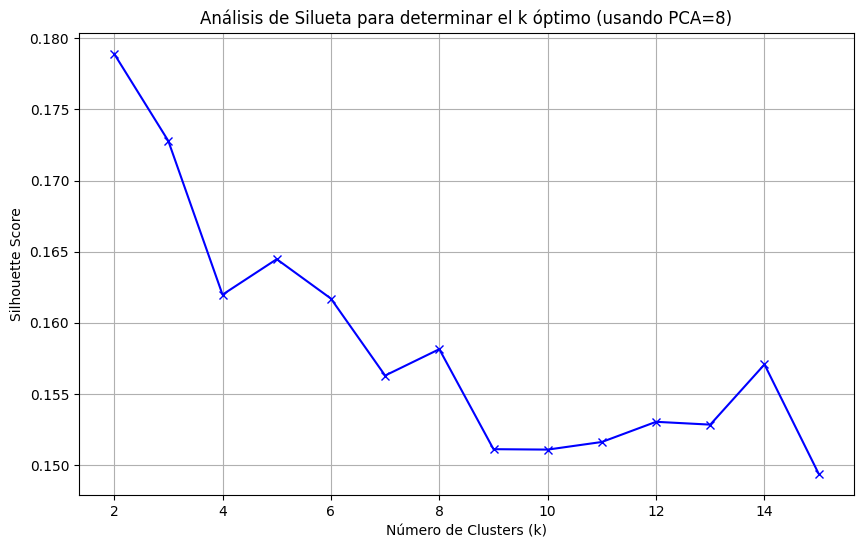

In [35]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. PREPARAR LOS DATOS PCA (Con tus 8 componentes decididos)
# ----------------------------------------------------------
pca_final = PCA(n_components=8)
X_pca = pca_final.fit_transform(datos_escalados) # Usamos los datos escalados del paso anterior

print(f"Datos listos para clustering. Forma: {X_pca.shape}")


# 2. BUCLE PARA CALCULAR SILHOUETTE SCORE
# ----------------------------------------------------------
# Probaremos desde 2 hasta 15 clusters (puedes aumentar el rango si crees que hay muchos géneros)
rango_n_clusters = range(2, 16)
silhouette_avg = []

print("Calculando Silhouette Scores... (esto puede tardar un poco dependiendo del tamaño de los datos)")

for k in rango_n_clusters:
    # Ejecutamos K-Means para k clusters
    # random_state asegura que si lo corres de nuevo, salga lo mismo
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_pca)

    # Calculamos el score de silueta
    score = silhouette_score(X_pca, cluster_labels)
    silhouette_avg.append(score)
    print(f"k={k} : Score={score:.4f}")


# 3. GRAFICAR LOS RESULTADOS
# ----------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(rango_n_clusters, silhouette_avg, 'bx-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Análisis de Silueta para determinar el k óptimo (usando PCA=8)')
plt.grid(True)
plt.show()

In [36]:
# 1. Entrenar el modelo final con k=5
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_final.fit(X_pca)

# 2. Obtener las etiquetas (a qué cluster pertenece cada canción)
labels = kmeans_final.labels_

# 3.
df_final['Cluster'] = labels

# 4. Analizar qué significa cada cluster
# Agrupamos por cluster y sacamos la media de cada variable
analisis_clusters = df_final.groupby('Cluster').mean()

print("Cantidad de canciones por cluster:")
print(df_final['Cluster'].value_counts())

# Mostramos el perfil promedio de cada cluster
analisis_clusters

Cantidad de canciones por cluster:
Cluster
1    12720
0    10965
3    10405
2     6853
4     1362
Name: count, dtype: int64


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
Cluster,,,,,,,,,,,,,
0,0.756802,0.723115,5.148108,-5.953587,0.627998,0.222821,0.105704,0.035525,0.196594,0.572530,153.566361,197265.719015,4.015230
1,0.507185,0.880866,5.283884,-4.192190,0.486714,0.114709,0.031198,0.191750,0.275101,0.267543,152.821055,226798.824843,4.008648
2,0.682106,0.495890,5.098789,-9.507229,0.536116,0.151946,0.306602,0.090581,0.153968,0.298241,145.046387,190781.912155,4.025390
3,0.659185,0.843055,5.902259,-7.646037,0.548390,0.062596,0.017823,0.781775,0.197834,0.287760,136.163624,377541.614897,4.004901
4,0.561884,0.700686,5.266520,-7.492462,0.578561,0.133820,0.165633,0.286794,0.211512,0.285055,147.111284,241726.164464,2.779736


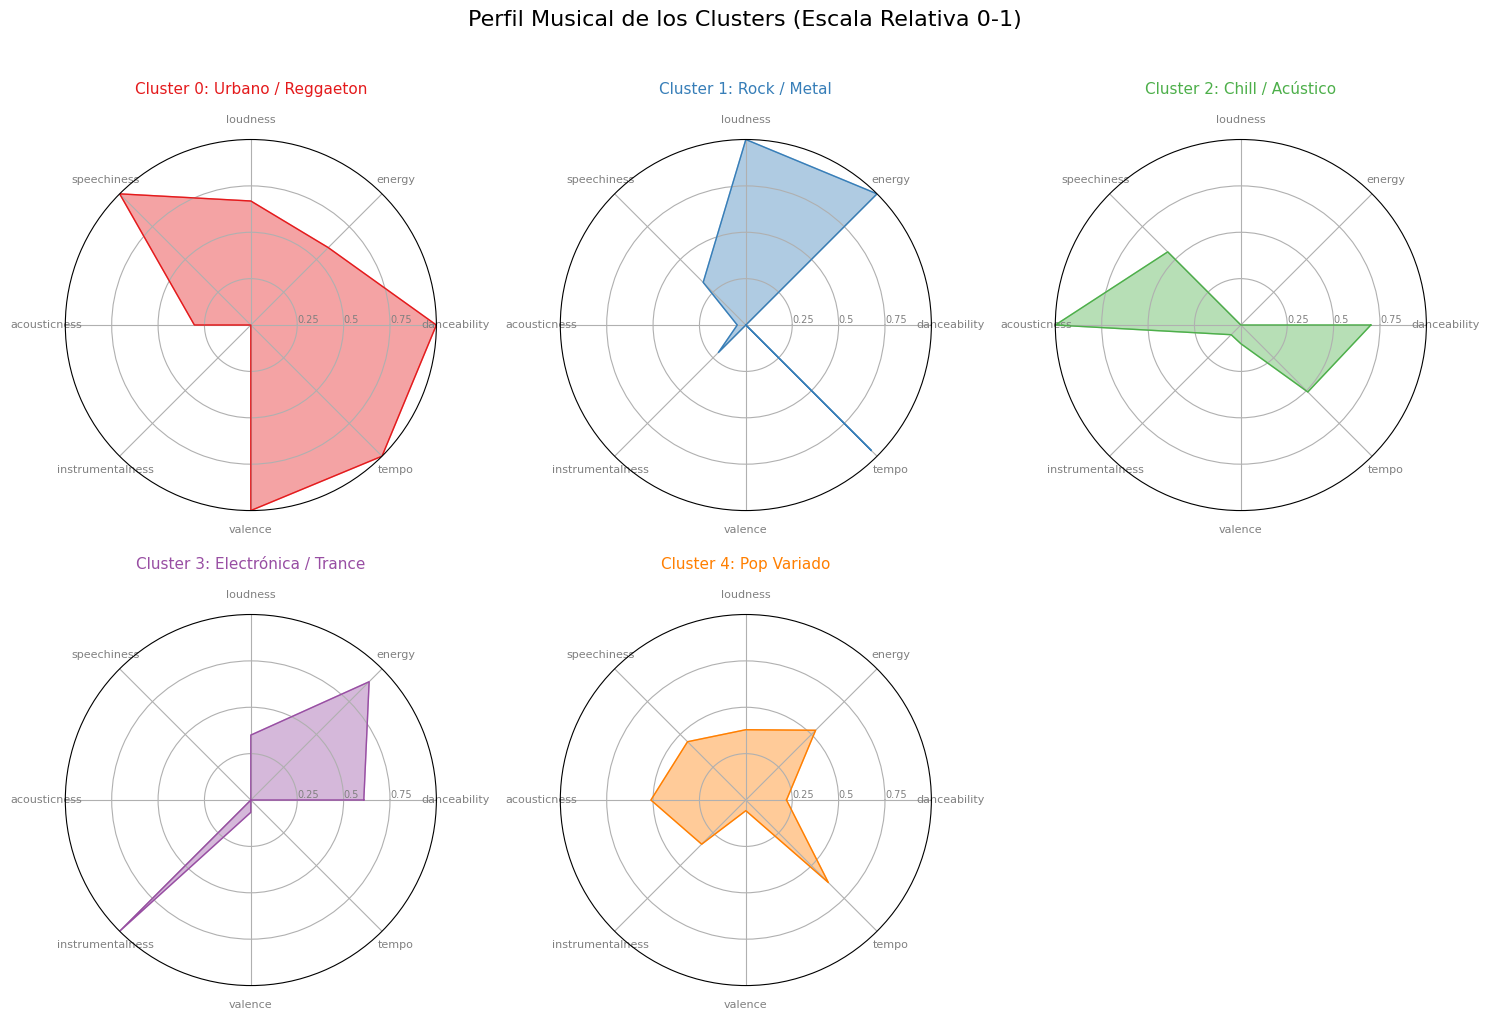

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
from math import pi
from sklearn.preprocessing import MinMaxScaler

# --- 1. PREPARACIÓN DE DATOS
features_to_plot = ['danceability', 'energy', 'loudness', 'speechiness',
                    'acousticness', 'instrumentalness', 'valence', 'tempo']
df_radar = analisis_clusters[features_to_plot].copy()

# Escalado Min-Max
scaler_radar = MinMaxScaler()
df_radar_scaled = pd.DataFrame(scaler_radar.fit_transform(df_radar),
                               columns=df_radar.columns,
                               index=df_radar.index)

# --- 2. FUNCIÓN DE GRAFICADO CORREGIDA ---
def make_spider(row, grid_pos, title, color):
    # Número de variables
    categories = list(df_radar_scaled.columns)
    N = len(categories)

    # Ángulo de cada eje
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    values = row.values.flatten().tolist()
    values += values[:1]
    ax = plt.subplot(2, 3, grid_pos + 1, polar=True)

    # Ejes
    plt.xticks(angles[:-1], categories, color='grey', size=8)

    # Eje Y
    ax.set_rlabel_position(0)
    plt.yticks([0.25, 0.5, 0.75], ["0.25","0.5","0.75"], color="grey", size=7)
    plt.ylim(0, 1)

    # Dibujar
    ax.plot(angles, values, linewidth=1, linestyle='solid', color=color)
    ax.fill(angles, values, color=color, alpha=0.4)

    # Título
    plt.title(title, size=11, color=color, y=1.1)

# --- 3. GENERAR EL GRÁFICO ---
plt.figure(figsize=(15, 10))
plt.suptitle("Perfil Musical de los Clusters (Escala Relativa 0-1)", fontsize=16, y=1.02)

# Diccionario de nombres (asegúrate que coincidan con tus IDs de cluster)
nombres_clusters = {
    0: "Urbano / Reggaeton",
    1: "Rock / Metal",
    2: "Chill / Acústico",
    3: "Electrónica / Trance",
    4: "Pop Variado"
}

# Obtener paleta de colores (forma moderna para evitar warnings)
import matplotlib as mpl
cmap = mpl.colormaps['Set1']

# Bucle corregido: pasamos 'i' explícitamente para la posición
for i, idx in enumerate(df_radar_scaled.index):
    make_spider(row=df_radar_scaled.loc[[idx]],
                grid_pos=i,  # <--- AQUÍ ESTABA EL ERROR, ahora pasamos la posición manual
                title=f"Cluster {idx}: {nombres_clusters.get(idx, 'Desconocido')}",
                color=cmap(i))

plt.tight_layout()
plt.show()